## 1. Setup and Imports

In [1]:
# Install required packages
!pip install -q ucimlrepo


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from numpy.linalg import svd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Suppress warnings
warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [3]:
# Check for GPU availability and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Using device: cuda
GPU: NVIDIA RTX A6000
CUDA Version: 11.8


## 2. Load and Prepare Taiwan Credit Dataset

In [4]:
# Fetch the dataset (ID 350 = Default of Credit Card Clients)
print("Fetching dataset from UCI Repository...")
taiwan_credit = fetch_ucirepo(id=350)
X_raw = taiwan_credit.data.features
y_raw = taiwan_credit.data.targets

# Combine into a single dataframe
df = pd.concat([X_raw, y_raw], axis=1)
target_col = y_raw.columns[0]
feature_names = X_raw.columns.tolist()

print(f"Dataset Loaded: {df.shape[0]} rows, {len(feature_names)} features.")
print(f"Feature names: {feature_names}")

Fetching dataset from UCI Repository...
Dataset Loaded: 30000 rows, 23 features.
Feature names: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


In [5]:
# Balance the dataset (Undersampling)
df_default = df[df[target_col] == 1]
df_no_default = df[df[target_col] == 0].sample(len(df_default), random_state=42)
df_balanced = pd.concat([df_default, df_no_default]).sample(frac=1, random_state=42)

# Normalize features to [0, 1]
scaler = MinMaxScaler()
df_balanced[feature_names] = scaler.fit_transform(df_balanced[feature_names])

# Calculate feature weights (Correlation with target)
weights = abs(df_balanced.corr()[target_col]).drop(target_col).values
weights = weights / (np.linalg.norm(weights) + 1e-8)

# Define bounds for the attack
bounds = [df_balanced[feature_names].min().values, df_balanced[feature_names].max().values]

print(f"Balanced Dataset Size: {len(df_balanced)} samples.")

Balanced Dataset Size: 13272 samples.


## 3. Define Model and Attack Functions (GPU-enabled)

In [6]:
class TaiwanNet(nn.Module):
    """Neural network for Taiwan Credit dataset classification."""
    def __init__(self, D_in):
        super(TaiwanNet, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )
    
    def forward(self, x):
        # Handle both single samples and batches
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)

In [7]:
def clip(current, low_bound, up_bound, device):
    """Clip tensor values to be within bounds."""
    low_bound = torch.FloatTensor(low_bound).to(device)
    up_bound = torch.FloatTensor(up_bound).to(device)
    return torch.max(torch.min(current, up_bound), low_bound)


def lowProFool_gpu(x, model, weights, bounds, maxiters, alpha, lambda_, device):
    """
    LowProFool attack with GPU support.
    
    Args:
        x: Input sample (tensor on device)
        model: Neural network model
        weights: Feature importance weights
        bounds: [lower_bounds, upper_bounds] for clipping
        maxiters: Maximum iterations
        alpha: Step size
        lambda_: Regularization parameter (stealth factor)
        device: torch device (cuda or cpu)
    
    Returns:
        orig_pred: Original prediction
        adv_pred: Adversarial prediction
        x_adv: Adversarial example (numpy array)
    """
    x = x.to(device)
    v = torch.FloatTensor(np.array(weights)).to(device)
    
    # Initialize perturbation
    r = torch.FloatTensor(1e-4 * np.ones(x.shape)).to(device)
    r.requires_grad = True
    
    # Get original prediction
    with torch.no_grad():
        output = model(x)
        orig_pred = output.argmax().cpu().item()
    
    # Set target (opposite class)
    target_pred = 1 - orig_pred
    target = torch.tensor([0., 1.] if target_pred == 1 else [1., 0.]).to(device)
    
    bce = nn.BCELoss()
    
    # Optimization loop
    for _ in range(maxiters):
        if r.grad is not None:
            r.grad.zero_()
        
        output = model(x + r)
        
        # Loss: BCE + lambda * weighted L2 norm
        loss_bce = bce(output, target)
        loss_l2 = torch.sqrt(torch.sum((v * r) ** 2))
        loss = loss_bce + lambda_ * loss_l2
        
        loss.backward(retain_graph=True)
        
        # Update perturbation
        with torch.no_grad():
            r_new = r - alpha * r.grad
        r = r_new.clone().detach().requires_grad_(True)
    
    # Final adversarial example
    x_adv = clip(x + r, bounds[0], bounds[1], device)
    
    with torch.no_grad():
        adv_pred = model(x_adv).argmax().cpu().item()
    
    return orig_pred, adv_pred, x_adv.detach().cpu().numpy()

## 4. Train the Model

In [8]:
# Prepare PyTorch tensors
X_tensor = torch.FloatTensor(df_balanced[feature_names].values)
y_tensor = torch.nn.functional.one_hot(torch.LongTensor(df_balanced[target_col].values.astype(int))).float()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

# Move to device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 10617 samples
Test set: 2655 samples


In [9]:
# Initialize and train model
model = TaiwanNet(len(feature_names)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print("Training model...")
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {loss.item():.4f}")

model.eval()
print("Training Complete.")

# Evaluate model accuracy
with torch.no_grad():
    train_acc = (model(X_train).argmax(dim=1) == y_train.argmax(dim=1)).float().mean()
    test_acc = (model(X_test).argmax(dim=1) == y_test.argmax(dim=1)).float().mean()
print(f"Train Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")

Training model...
Epoch 20/100, Loss: 0.6804
Epoch 40/100, Loss: 0.6462
Epoch 60/100, Loss: 0.6210
Epoch 80/100, Loss: 0.6070
Epoch 100/100, Loss: 0.5970
Training Complete.
Train Accuracy: 68.54%
Test Accuracy: 66.85%


## 5. Generate Adversarial Examples

We generate adversarial examples for all test samples using two lambda settings:
- **Aggressive attack** (λ = 0.1): Large perturbations, high success rate
- **Stealthy attack** (λ = 50.0): Small perturbations, more imperceptible

In [10]:
# Experiment parameters
ALPHA = 0.1
MAXITERS = 300
LAMBDAS = {'aggressive': 0.1, 'stealthy': 50.0}
N_SAMPLES = min(2000, X_test.shape[0])  # Use up to 2000 test samples

print(f"Experiment Parameters:")
print(f"  Alpha: {ALPHA}")
print(f"  Max iterations: {MAXITERS}")
print(f"  Lambda (aggressive): {LAMBDAS['aggressive']}")
print(f"  Lambda (stealthy): {LAMBDAS['stealthy']}")
print(f"  Number of samples: {N_SAMPLES}")

Experiment Parameters:
  Alpha: 0.1
  Max iterations: 300
  Lambda (aggressive): 0.1
  Lambda (stealthy): 50.0
  Number of samples: 2000


In [11]:
# Select test samples
test_samples = X_test[:N_SAMPLES].cpu()
original_data = test_samples.numpy()

# Storage for adversarial examples
adversarial_data = {}
attack_success = {}

for attack_type, lambda_val in LAMBDAS.items():
    print(f"\n--- Generating {attack_type} adversarial examples (λ={lambda_val}) ---")
    
    adv_samples = []
    successful = 0
    
    for i, x in enumerate(tqdm(test_samples, desc=f"LowProFool ({attack_type})")):
        orig_pred, adv_pred, x_adv = lowProFool_gpu(
            x, model, weights, bounds, MAXITERS, ALPHA, lambda_val, device
        )
        adv_samples.append(x_adv)
        if orig_pred != adv_pred:
            successful += 1
    
    adversarial_data[attack_type] = np.array(adv_samples)
    attack_success[attack_type] = successful / N_SAMPLES
    
    print(f"Success rate ({attack_type}): {attack_success[attack_type]:.2%}")
    
    # Calculate average perturbation magnitude
    perturbation = adversarial_data[attack_type] - original_data
    avg_l2_norm = np.mean(np.linalg.norm(perturbation, axis=1))
    print(f"Average L2 perturbation ({attack_type}): {avg_l2_norm:.6f}")


--- Generating aggressive adversarial examples (λ=0.1) ---


LowProFool (aggressive): 100%|██████████| 2000/2000 [10:21<00:00,  3.22it/s]


Success rate (aggressive): 100.00%
Average L2 perturbation (aggressive): 1.165905

--- Generating stealthy adversarial examples (λ=50.0) ---


LowProFool (stealthy): 100%|██████████| 2000/2000 [11:25<00:00,  2.92it/s]

Success rate (stealthy): 73.25%
Average L2 perturbation (stealthy): 1.090775


## 6. Generate Random Noise Control

For comparison, we create a control experiment with random Gaussian noise that has the same average L2 norm as the aggressive attack.

In [12]:
# Calculate target noise magnitude (match aggressive attack)
aggressive_perturbation = adversarial_data['aggressive'] - original_data
target_l2_norms = np.linalg.norm(aggressive_perturbation, axis=1)

# Generate random noise with matching L2 norms
np.random.seed(42)
random_noise = np.random.randn(*original_data.shape)

# Normalize each sample's noise to match the corresponding attack perturbation
noise_norms = np.linalg.norm(random_noise, axis=1, keepdims=True)
random_noise = random_noise / (noise_norms + 1e-8) * target_l2_norms.reshape(-1, 1)

# Create noisy data
noisy_data = np.clip(original_data + random_noise, bounds[0], bounds[1])

print(f"Random noise control created.")
print(f"Average L2 noise magnitude: {np.mean(np.linalg.norm(noisy_data - original_data, axis=1)):.6f}")

Random noise control created.
Average L2 noise magnitude: 0.916905


## 7. SVD Analysis with Gradual Substitution

We gradually replace clean data with attacked/noisy data and observe how the SVD spectrum changes.

In [13]:
def compute_svd_metrics(data_matrix):
    """
    Compute SVD and extract metrics.
    
    Returns:
        singular_values: Array of singular values
        cliff_steepness: Ratio of first to second singular value
        tail_magnitude: Mean of bottom 50% singular values
        spectral_entropy: Normalized entropy of singular value distribution
    """
    _, s, _ = svd(data_matrix, full_matrices=False)
    
    # Cliff steepness: ratio of σ_0 to σ_1
    cliff_steepness = s[0] / (s[1] + 1e-8)
    
    # Tail magnitude: mean of bottom 50% singular values
    tail_start = len(s) // 2
    tail_magnitude = np.mean(s[tail_start:])
    
    # Spectral entropy (normalized)
    s_normalized = s / (np.sum(s) + 1e-8)
    spectral_entropy = -np.sum(s_normalized * np.log(s_normalized + 1e-10))
    spectral_entropy /= np.log(len(s))  # Normalize
    
    return s, cliff_steepness, tail_magnitude, spectral_entropy

In [14]:
# Experiment settings
PROPORTIONS = np.arange(0, 1.1, 0.1)  # 0%, 10%, ..., 100%
N_TRIALS = 5

# Data sources to compare
data_sources = {
    'aggressive': adversarial_data['aggressive'],
    'stealthy': adversarial_data['stealthy'],
    'random_noise': noisy_data
}

# Storage for results
results = {source: {'proportions': [], 'singular_values': [], 
                    'cliff_steepness': [], 'tail_magnitude': [], 
                    'spectral_entropy': []} 
           for source in data_sources.keys()}

print(f"Running SVD analysis with {N_TRIALS} trials per proportion...")
print(f"Proportions: {[f'{p:.0%}' for p in PROPORTIONS]}")

Running SVD analysis with 5 trials per proportion...
Proportions: ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']


In [15]:
for source_name, modified_data in data_sources.items():
    print(f"\n--- Processing {source_name} ---")
    
    for prop in tqdm(PROPORTIONS, desc=source_name):
        prop_sv = []  # Singular values across trials
        prop_cliff = []
        prop_tail = []
        prop_entropy = []
        
        for trial in range(N_TRIALS):
            # Set random seed for reproducibility
            np.random.seed(trial * 100 + int(prop * 10))
            
            # Randomly select indices to replace
            n_replace = int(N_SAMPLES * prop)
            replace_indices = np.random.choice(N_SAMPLES, n_replace, replace=False)
            
            # Create mixed dataset
            mixed_data = original_data.copy()
            mixed_data[replace_indices] = modified_data[replace_indices]
            
            # Compute SVD metrics
            sv, cliff, tail, entropy = compute_svd_metrics(mixed_data)
            
            prop_sv.append(sv)
            prop_cliff.append(cliff)
            prop_tail.append(tail)
            prop_entropy.append(entropy)
        
        # Store averaged results
        results[source_name]['proportions'].append(prop)
        results[source_name]['singular_values'].append(np.mean(prop_sv, axis=0))
        results[source_name]['cliff_steepness'].append(np.mean(prop_cliff))
        results[source_name]['tail_magnitude'].append(np.mean(prop_tail))
        results[source_name]['spectral_entropy'].append(np.mean(prop_entropy))

print("\nSVD analysis complete!")


--- Processing aggressive ---


aggressive: 100%|██████████| 11/11 [00:00<00:00, 19.61it/s]



--- Processing stealthy ---


stealthy: 100%|██████████| 11/11 [00:00<00:00, 65.75it/s]



--- Processing random_noise ---


random_noise: 100%|██████████| 11/11 [00:00<00:00, 44.38it/s]


SVD analysis complete!


## 8. Visualization

### 8.1 SVD Spectrum Overlay at Different Proportions

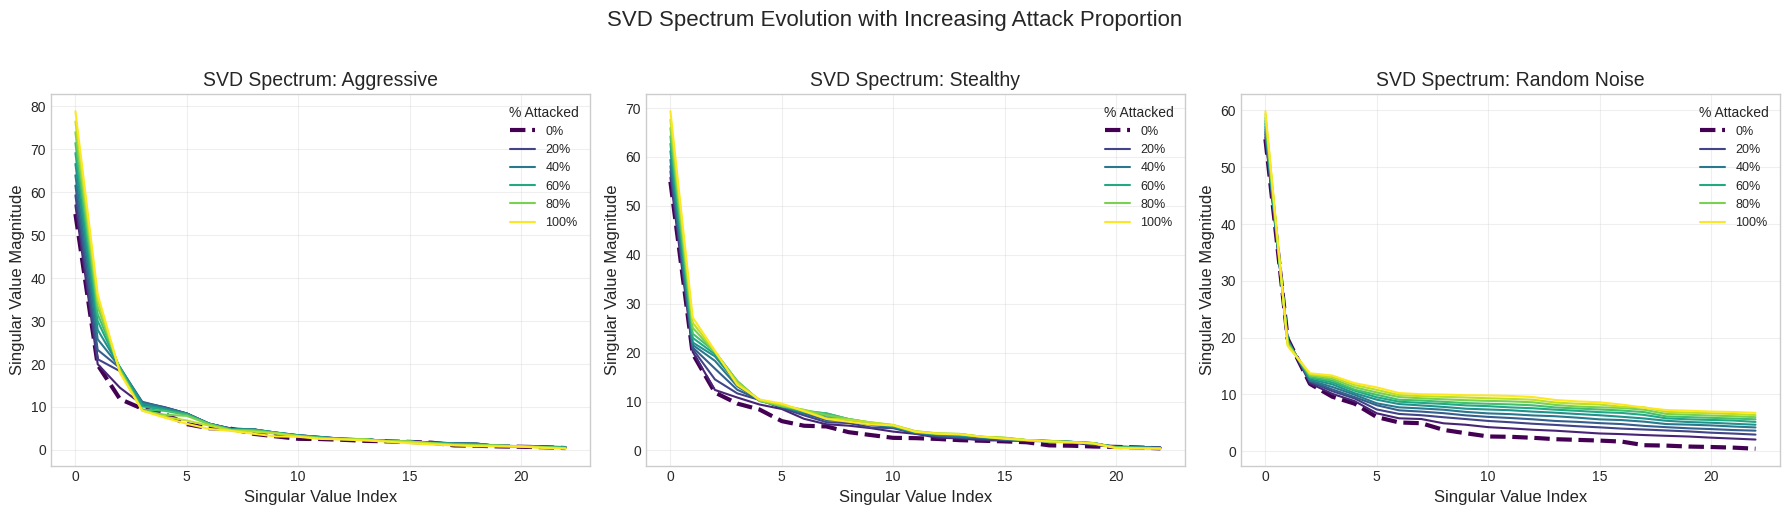

In [16]:
# Plot SVD spectrum evolution for each attack type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Color map for proportions
colors = plt.cm.viridis(np.linspace(0, 1, len(PROPORTIONS)))

for ax, (source_name, data) in zip(axes, results.items()):
    for i, (prop, sv) in enumerate(zip(data['proportions'], data['singular_values'])):
        label = f"{prop:.0%}" if i % 2 == 0 else None  # Label every other line
        linewidth = 3 if prop == 0 else 1.5
        linestyle = '--' if prop == 0 else '-'
        ax.plot(sv, color=colors[i], label=label, linewidth=linewidth, linestyle=linestyle)
    
    ax.set_title(f'SVD Spectrum: {source_name.replace("_", " ").title()}', fontsize=14)
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Singular Value Magnitude', fontsize=12)
    ax.legend(title='% Attacked', loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('SVD Spectrum Evolution with Increasing Attack Proportion', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('svd_spectrum_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Cliff Steepness vs Proportion

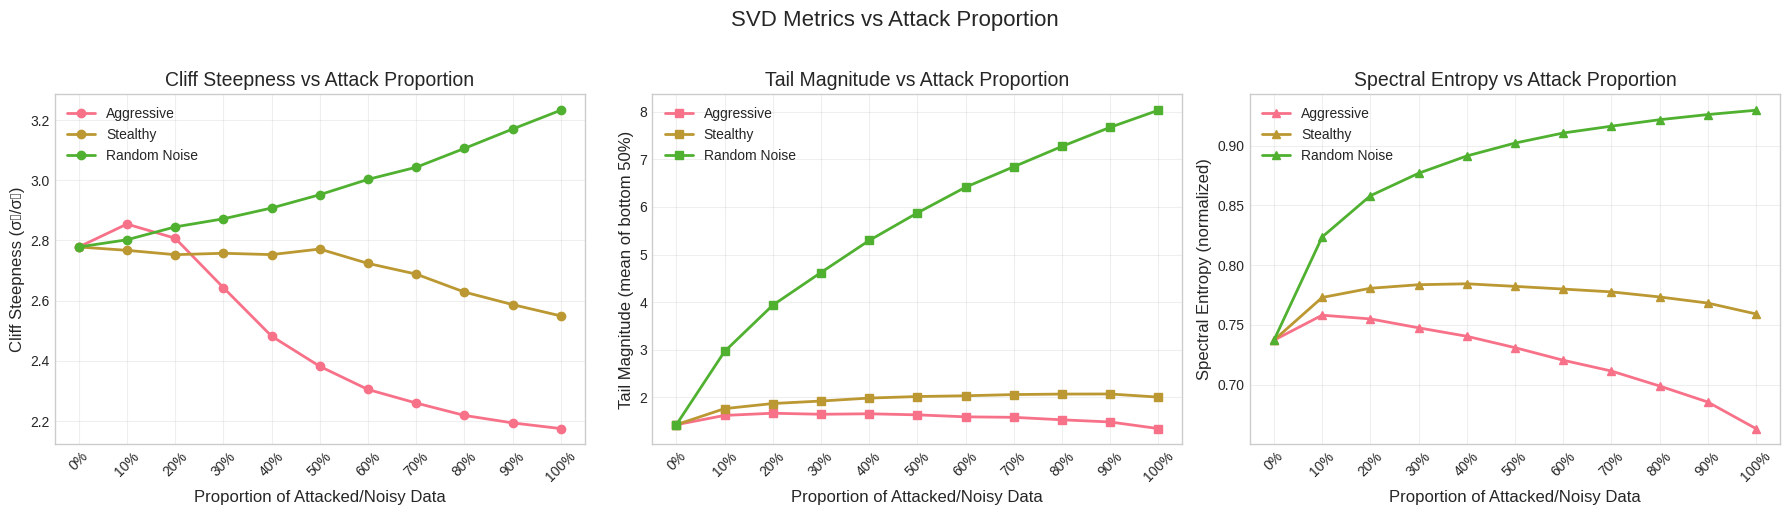

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Cliff Steepness
ax1 = axes[0]
for source_name, data in results.items():
    ax1.plot(data['proportions'], data['cliff_steepness'], 
             marker='o', label=source_name.replace('_', ' ').title(), linewidth=2)
ax1.set_xlabel('Proportion of Attacked/Noisy Data', fontsize=12)
ax1.set_ylabel('Cliff Steepness (σ₀/σ₁)', fontsize=12)
ax1.set_title('Cliff Steepness vs Attack Proportion', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(PROPORTIONS)
ax1.set_xticklabels([f'{p:.0%}' for p in PROPORTIONS], rotation=45)

# Plot 2: Tail Magnitude
ax2 = axes[1]
for source_name, data in results.items():
    ax2.plot(data['proportions'], data['tail_magnitude'], 
             marker='s', label=source_name.replace('_', ' ').title(), linewidth=2)
ax2.set_xlabel('Proportion of Attacked/Noisy Data', fontsize=12)
ax2.set_ylabel('Tail Magnitude (mean of bottom 50%)', fontsize=12)
ax2.set_title('Tail Magnitude vs Attack Proportion', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(PROPORTIONS)
ax2.set_xticklabels([f'{p:.0%}' for p in PROPORTIONS], rotation=45)

# Plot 3: Spectral Entropy
ax3 = axes[2]
for source_name, data in results.items():
    ax3.plot(data['proportions'], data['spectral_entropy'], 
             marker='^', label=source_name.replace('_', ' ').title(), linewidth=2)
ax3.set_xlabel('Proportion of Attacked/Noisy Data', fontsize=12)
ax3.set_ylabel('Spectral Entropy (normalized)', fontsize=12)
ax3.set_title('Spectral Entropy vs Attack Proportion', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(PROPORTIONS)
ax3.set_xticklabels([f'{p:.0%}' for p in PROPORTIONS], rotation=45)

plt.suptitle('SVD Metrics vs Attack Proportion', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('svd_metrics_vs_proportion.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Direct Comparison: Original vs 100% Attacked

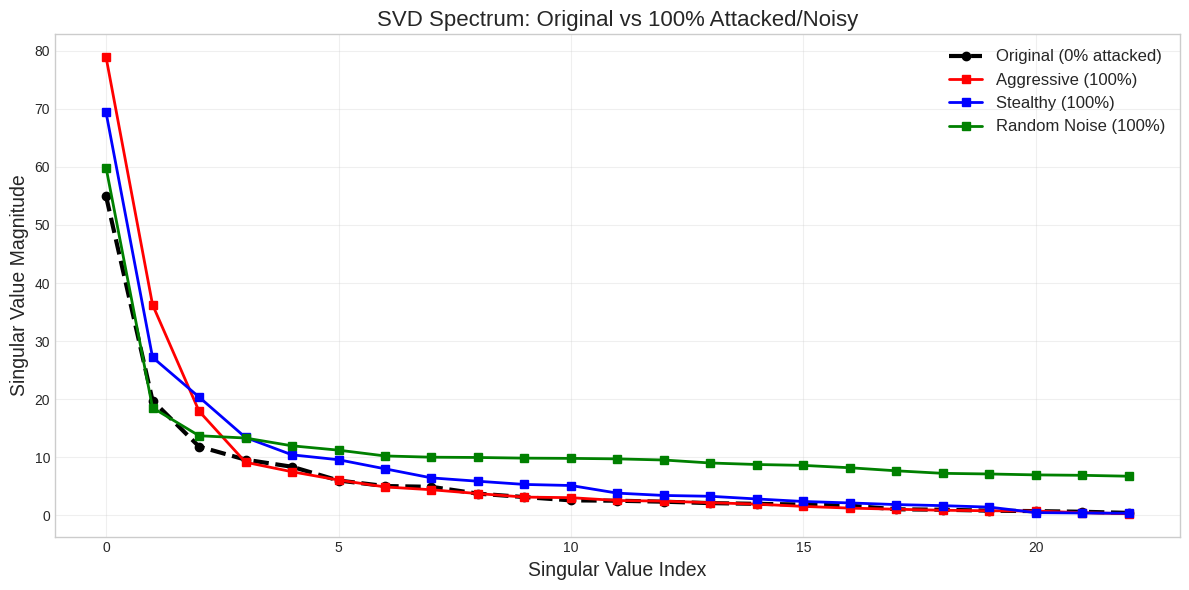

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

# Original data SVD (0% attacked)
sv_original = results['aggressive']['singular_values'][0]  # Same for all at 0%
ax.plot(sv_original, 'k--', linewidth=3, label='Original (0% attacked)', marker='o')

# 100% attacked for each type
colors = {'aggressive': 'red', 'stealthy': 'blue', 'random_noise': 'green'}
for source_name, data in results.items():
    sv_100 = data['singular_values'][-1]  # Last entry is 100%
    ax.plot(sv_100, color=colors[source_name], linewidth=2, 
            label=f'{source_name.replace("_", " ").title()} (100%)', marker='s')

ax.set_xlabel('Singular Value Index', fontsize=14)
ax.set_ylabel('Singular Value Magnitude', fontsize=14)
ax.set_title('SVD Spectrum: Original vs 100% Attacked/Noisy', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svd_original_vs_attacked.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Heatmap of Singular Values vs Proportion

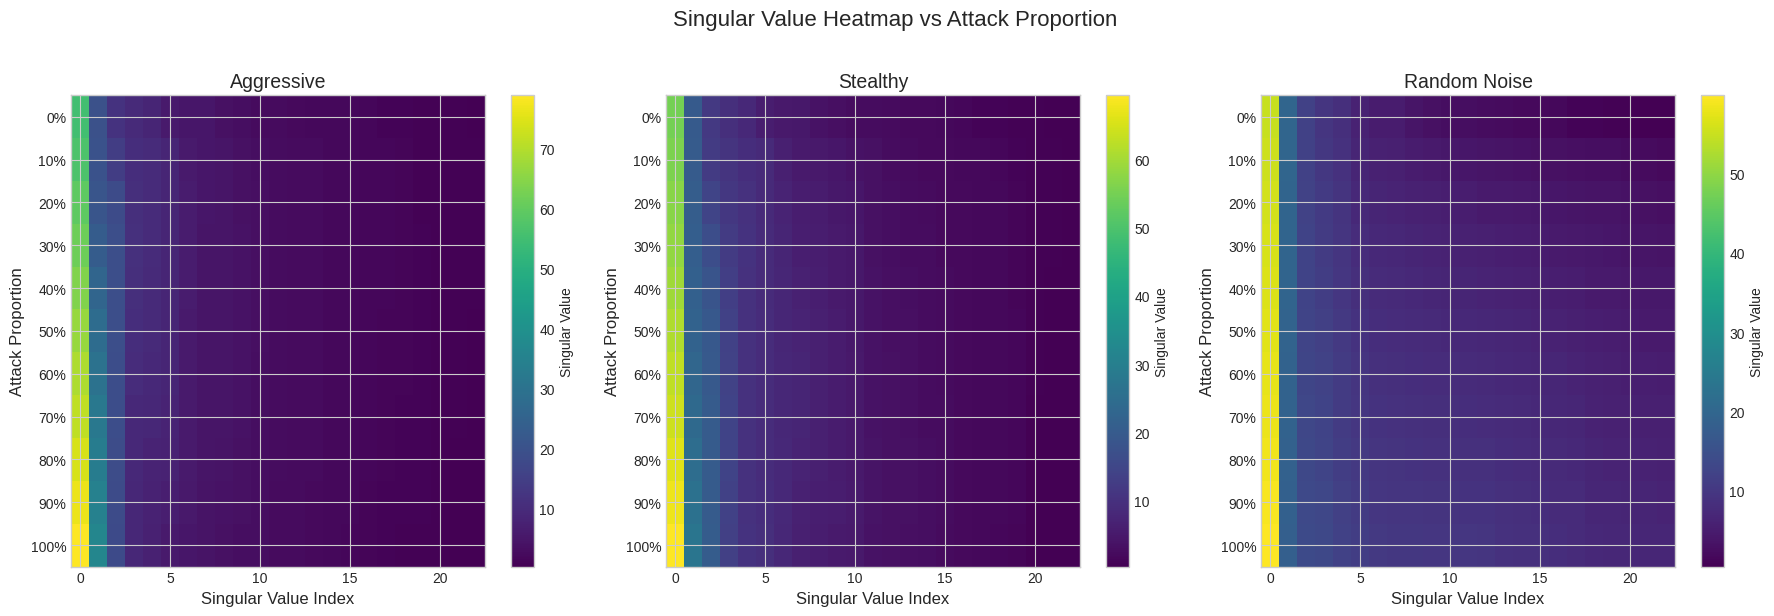

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (source_name, data) in zip(axes, results.items()):
    # Create matrix: rows = proportions, cols = singular value indices
    sv_matrix = np.array(data['singular_values'])
    
    im = ax.imshow(sv_matrix, aspect='auto', cmap='viridis')
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Attack Proportion', fontsize=12)
    ax.set_title(f'{source_name.replace("_", " ").title()}', fontsize=14)
    ax.set_yticks(range(len(PROPORTIONS)))
    ax.set_yticklabels([f'{p:.0%}' for p in PROPORTIONS])
    plt.colorbar(im, ax=ax, label='Singular Value')

plt.suptitle('Singular Value Heatmap vs Attack Proportion', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('svd_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary and Conclusions

In [20]:
# Create summary table
print("=" * 80)
print("EXPERIMENT SUMMARY")
print("=" * 80)

print(f"\nDataset: Taiwan Credit ({N_SAMPLES} samples, {len(feature_names)} features)")
print(f"Attack: LowProFool (α={ALPHA}, iterations={MAXITERS})")
print(f"Trials per proportion: {N_TRIALS}")

print("\n" + "-" * 80)
print("ATTACK SUCCESS RATES:")
print("-" * 80)
for attack_type, rate in attack_success.items():
    print(f"  {attack_type:12s}: {rate:.2%}")

print("\n" + "-" * 80)
print("SVD METRIC CHANGES (0% → 100% attacked):")
print("-" * 80)

for source_name, data in results.items():
    cliff_change = data['cliff_steepness'][-1] - data['cliff_steepness'][0]
    tail_change = data['tail_magnitude'][-1] - data['tail_magnitude'][0]
    entropy_change = data['spectral_entropy'][-1] - data['spectral_entropy'][0]
    
    print(f"\n  {source_name.upper()}:")
    print(f"    Cliff steepness: {data['cliff_steepness'][0]:.3f} → {data['cliff_steepness'][-1]:.3f} (Δ={cliff_change:+.3f})")
    print(f"    Tail magnitude:  {data['tail_magnitude'][0]:.3f} → {data['tail_magnitude'][-1]:.3f} (Δ={tail_change:+.3f})")
    print(f"    Spectral entropy:{data['spectral_entropy'][0]:.3f} → {data['spectral_entropy'][-1]:.3f} (Δ={entropy_change:+.3f})")

print("\n" + "=" * 80)
print("HYPOTHESIS EVALUATION:")
print("=" * 80)
print("""
Hypothesis: Adding adversarial examples smooths the cliff and/or lifts the tail.

Observations to check:
1. Does cliff steepness DECREASE as attack proportion increases? (cliff smoothing)
2. Does tail magnitude INCREASE as attack proportion increases? (tail lifting)
3. Does spectral entropy INCREASE as attack proportion increases? (more spread out)
4. Is the effect more pronounced for aggressive vs stealthy attacks?
5. How does adversarial attack compare to random noise?
""")

EXPERIMENT SUMMARY

Dataset: Taiwan Credit (2000 samples, 23 features)
Attack: LowProFool (α=0.1, iterations=300)
Trials per proportion: 5

--------------------------------------------------------------------------------
ATTACK SUCCESS RATES:
--------------------------------------------------------------------------------
  aggressive  : 100.00%
  stealthy    : 73.25%

--------------------------------------------------------------------------------
SVD METRIC CHANGES (0% → 100% attacked):
--------------------------------------------------------------------------------

  AGGRESSIVE:
    Cliff steepness: 2.778 → 2.175 (Δ=-0.603)
    Tail magnitude:  1.421 → 1.340 (Δ=-0.081)
    Spectral entropy:0.737 → 0.663 (Δ=-0.074)

  STEALTHY:
    Cliff steepness: 2.778 → 2.550 (Δ=-0.229)
    Tail magnitude:  1.421 → 2.002 (Δ=+0.581)
    Spectral entropy:0.737 → 0.759 (Δ=+0.022)

  RANDOM_NOISE:
    Cliff steepness: 2.778 → 3.233 (Δ=+0.454)
    Tail magnitude:  1.421 → 8.035 (Δ=+6.613)
    Spectral

In [21]:
# Quantitative hypothesis testing
print("\n" + "=" * 80)
print("QUANTITATIVE HYPOTHESIS TESTING:")
print("=" * 80)

for source_name, data in results.items():
    cliff = np.array(data['cliff_steepness'])
    tail = np.array(data['tail_magnitude'])
    props = np.array(data['proportions'])
    
    # Compute correlation with proportion
    cliff_corr = np.corrcoef(props, cliff)[0, 1]
    tail_corr = np.corrcoef(props, tail)[0, 1]
    
    print(f"\n{source_name.upper()}:")
    print(f"  Cliff steepness correlation with proportion: {cliff_corr:+.3f}")
    print(f"    → {'SUPPORTS' if cliff_corr < -0.5 else 'WEAK/NO SUPPORT for'} 'cliff smoothing' hypothesis")
    print(f"  Tail magnitude correlation with proportion:  {tail_corr:+.3f}")
    print(f"    → {'SUPPORTS' if tail_corr > 0.5 else 'WEAK/NO SUPPORT for'} 'tail lifting' hypothesis")


QUANTITATIVE HYPOTHESIS TESTING:

AGGRESSIVE:
  Cliff steepness correlation with proportion: -0.959
    → SUPPORTS 'cliff smoothing' hypothesis
  Tail magnitude correlation with proportion:  -0.451
    → WEAK/NO SUPPORT for 'tail lifting' hypothesis

STEALTHY:
  Cliff steepness correlation with proportion: -0.895
    → SUPPORTS 'cliff smoothing' hypothesis
  Tail magnitude correlation with proportion:  +0.792
    → SUPPORTS 'tail lifting' hypothesis

RANDOM_NOISE:
  Cliff steepness correlation with proportion: +0.991
    → WEAK/NO SUPPORT for 'cliff smoothing' hypothesis
  Tail magnitude correlation with proportion:  +0.977
    → SUPPORTS 'tail lifting' hypothesis


## 10. Save Results

In [22]:
# Save results to CSV for further analysis
import json

# Convert numpy arrays to lists for JSON serialization
results_serializable = {}
for source_name, data in results.items():
    results_serializable[source_name] = {
        'proportions': [float(p) for p in data['proportions']],
        'singular_values': [sv.tolist() for sv in data['singular_values']],
        'cliff_steepness': [float(c) for c in data['cliff_steepness']],
        'tail_magnitude': [float(t) for t in data['tail_magnitude']],
        'spectral_entropy': [float(e) for e in data['spectral_entropy']]
    }

with open('svd_analysis_results.json', 'w') as f:
    json.dump(results_serializable, f, indent=2)

print("Results saved to svd_analysis_results.json")
print("Figures saved as PNG files.")

Results saved to svd_analysis_results.json
Figures saved as PNG files.


## 11. K-Rank Approximation Defense Analysis

This section tests whether a low-rank approximation of attacked data can "vaccinate" or restore the data, reducing the effectiveness of the attack.

**Idea**: If adversarial perturbations lie in the noise subspace (smaller singular values), then a k-rank approximation that keeps only the top-k singular values should remove the attack while preserving the data structure.

In [23]:
def k_rank_approximation(data_matrix, k):
    """
    Compute k-rank approximation of a data matrix using SVD.
    
    Args:
        data_matrix: numpy array of shape (n_samples, n_features)
        k: number of singular values to keep
    
    Returns:
        approximated matrix of same shape
    """
    U, s, Vh = svd(data_matrix, full_matrices=False)
    
    # Keep only top-k components
    U_k = U[:, :k]
    s_k = s[:k]
    Vh_k = Vh[:k, :]
    
    # Reconstruct
    approximated = U_k @ np.diag(s_k) @ Vh_k
    
    return approximated


def evaluate_attack_effectiveness(original_data, attacked_data, model, device):
    """
    Evaluate attack effectiveness by comparing predictions.
    
    Returns:
        attack_success_rate: proportion of samples where prediction changed
        original_preds: predictions on original data
        attacked_preds: predictions on attacked data
    """
    model.eval()
    
    with torch.no_grad():
        # Original predictions
        orig_tensor = torch.FloatTensor(original_data).to(device)
        original_preds = model(orig_tensor).argmax(dim=1).cpu().numpy()
        
        # Attacked predictions
        atk_tensor = torch.FloatTensor(attacked_data).to(device)
        attacked_preds = model(atk_tensor).argmax(dim=1).cpu().numpy()
    
    # Attack success = prediction changed
    attack_success_rate = np.mean(original_preds != attacked_preds)
    
    return attack_success_rate, original_preds, attacked_preds


print("Helper functions defined.")

Helper functions defined.


In [24]:
# K-rank approximation experiment parameters
n_features = original_data.shape[1]  # 23 features
K_VALUES = list(range(1, n_features + 1))  # k = 1, 2, ..., 23

print(f"Testing k-rank approximation for k = 1 to {n_features}")
print(f"Original data shape: {original_data.shape}")
print(f"Number of test samples: {original_data.shape[0]}")

Testing k-rank approximation for k = 1 to 23
Original data shape: (2000, 23)
Number of test samples: 2000


In [25]:
# Run k-rank approximation experiment
k_rank_results = {
    'aggressive': {'k': [], 'attack_success_before': [], 'attack_success_after': [], 'restoration_rate': []},
    'stealthy': {'k': [], 'attack_success_before': [], 'attack_success_after': [], 'restoration_rate': []}
}

# Get original predictions (ground truth for restoration)
_, original_preds, _ = evaluate_attack_effectiveness(original_data, original_data, model, device)

print("Running k-rank approximation defense experiment...\n")

for attack_type in ['aggressive', 'stealthy']:
    print(f"--- {attack_type.upper()} Attack ---")
    attacked_data = adversarial_data[attack_type]
    
    # Get attack success rate before defense
    attack_success_before, _, attacked_preds = evaluate_attack_effectiveness(
        original_data, attacked_data, model, device
    )
    print(f"Attack success rate (before defense): {attack_success_before:.2%}")
    
    for k in tqdm(K_VALUES, desc=f"K-rank ({attack_type})"):
        # Apply k-rank approximation to attacked data
        defended_data = k_rank_approximation(attacked_data, k)
        
        # Clip to valid bounds
        defended_data = np.clip(defended_data, bounds[0], bounds[1])
        
        # Evaluate attack effectiveness after defense
        attack_success_after, _, defended_preds = evaluate_attack_effectiveness(
            original_data, defended_data, model, device
        )
        
        # Restoration rate: how many attacked samples are restored to original prediction
        # (Only count samples that were successfully attacked)
        successfully_attacked_mask = (original_preds != attacked_preds)
        if successfully_attacked_mask.sum() > 0:
            restored = (defended_preds[successfully_attacked_mask] == original_preds[successfully_attacked_mask])
            restoration_rate = restored.sum() / successfully_attacked_mask.sum()
        else:
            restoration_rate = 0.0
        
        k_rank_results[attack_type]['k'].append(k)
        k_rank_results[attack_type]['attack_success_before'].append(attack_success_before)
        k_rank_results[attack_type]['attack_success_after'].append(attack_success_after)
        k_rank_results[attack_type]['restoration_rate'].append(restoration_rate)
    
    print(f"Best restoration at k={k_rank_results[attack_type]['k'][np.argmax(k_rank_results[attack_type]['restoration_rate'])]}: "
          f"{max(k_rank_results[attack_type]['restoration_rate']):.2%}\n")

print("K-rank approximation experiment complete!")

Running k-rank approximation defense experiment...

--- AGGRESSIVE Attack ---
Attack success rate (before defense): 100.00%


K-rank (aggressive): 100%|██████████| 23/23 [00:00<00:00, 106.62it/s]


Best restoration at k=1: 64.20%

--- STEALTHY Attack ---
Attack success rate (before defense): 73.25%


K-rank (stealthy): 100%|██████████| 23/23 [00:00<00:00, 103.47it/s]

Best restoration at k=1: 12.42%

K-rank approximation experiment complete!


### 11.1 K-Rank Defense Visualization

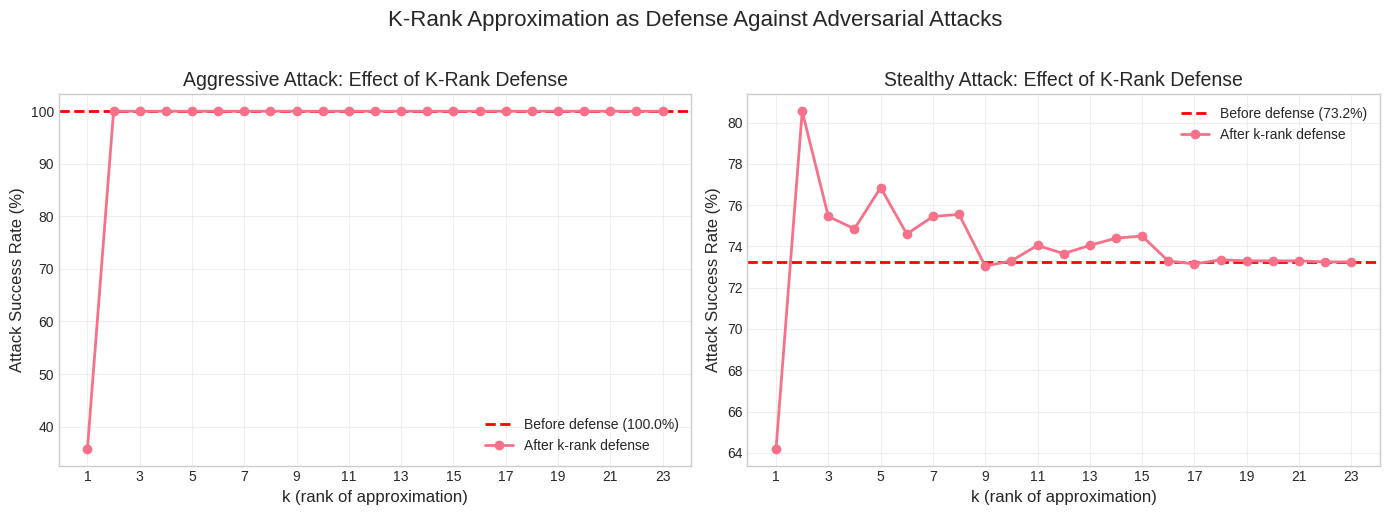

In [26]:
import os

# Create output directory
output_dir = 'k_rank_results'
os.makedirs(output_dir, exist_ok=True)

# Plot 1: Attack Success Rate vs K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attack_type in zip(axes, ['aggressive', 'stealthy']):
    data = k_rank_results[attack_type]
    
    ax.axhline(y=data['attack_success_before'][0] * 100, color='red', linestyle='--', 
               label=f'Before defense ({data["attack_success_before"][0]:.1%})', linewidth=2)
    ax.plot(data['k'], np.array(data['attack_success_after']) * 100, 
            marker='o', linewidth=2, label='After k-rank defense')
    
    ax.set_xlabel('k (rank of approximation)', fontsize=12)
    ax.set_ylabel('Attack Success Rate (%)', fontsize=12)
    ax.set_title(f'{attack_type.title()} Attack: Effect of K-Rank Defense', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(K_VALUES[::2])  # Every other k value

plt.suptitle('K-Rank Approximation as Defense Against Adversarial Attacks', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_attack_success.png'), dpi=150, bbox_inches='tight')
plt.show()

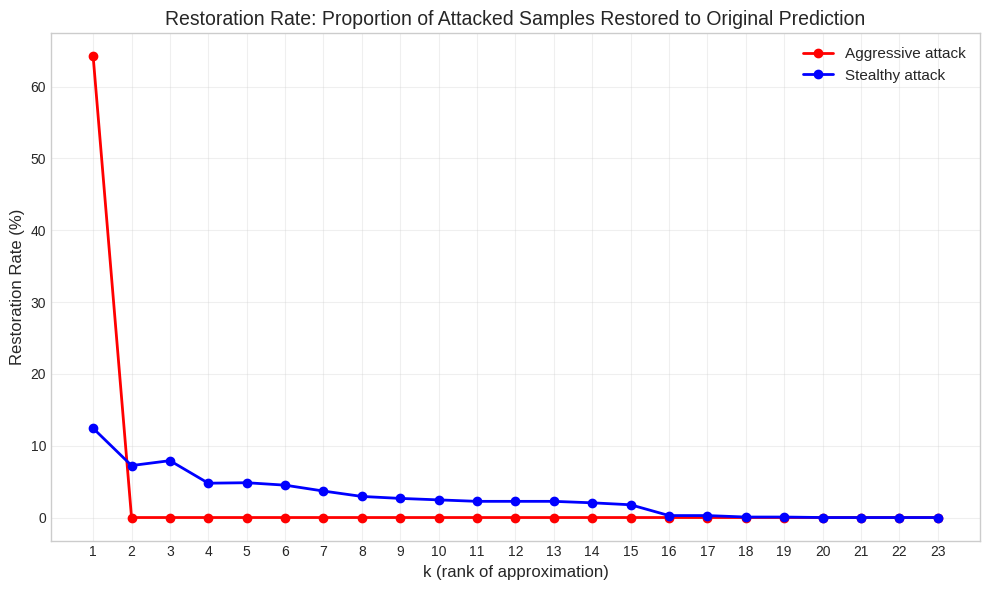

In [27]:
# Plot 2: Restoration Rate vs K
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'aggressive': 'red', 'stealthy': 'blue'}
for attack_type in ['aggressive', 'stealthy']:
    data = k_rank_results[attack_type]
    ax.plot(data['k'], np.array(data['restoration_rate']) * 100, 
            marker='o', linewidth=2, color=colors[attack_type],
            label=f'{attack_type.title()} attack')

ax.set_xlabel('k (rank of approximation)', fontsize=12)
ax.set_ylabel('Restoration Rate (%)', fontsize=12)
ax.set_title('Restoration Rate: Proportion of Attacked Samples Restored to Original Prediction', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(K_VALUES)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_restoration_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

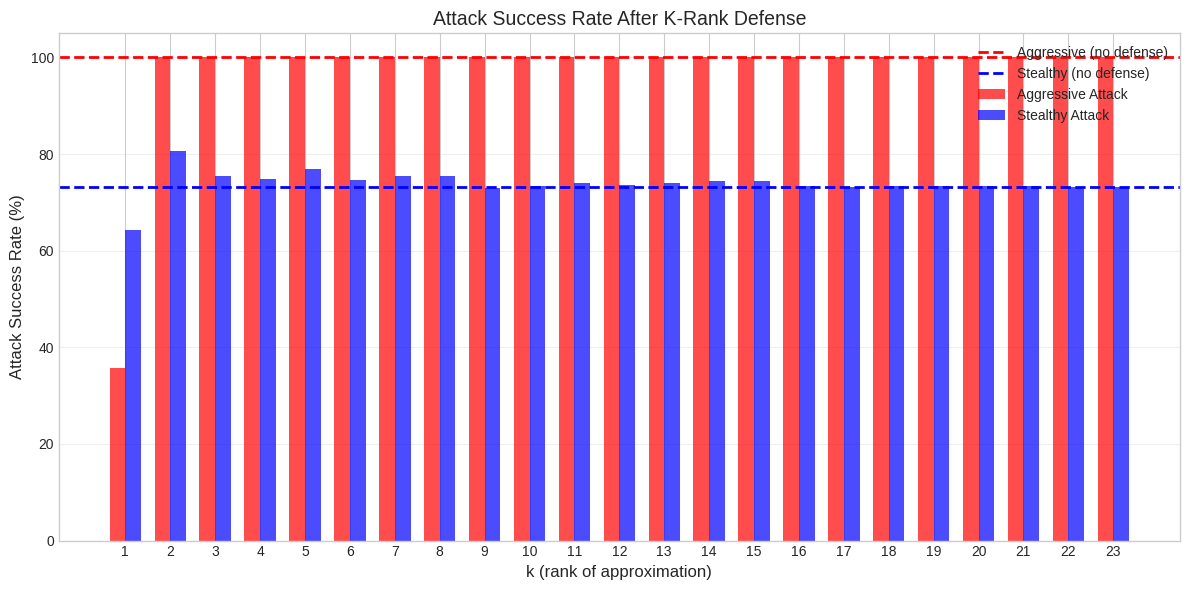

In [28]:
# Plot 3: Combined view - Attack success before vs after defense
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
x = np.arange(len(K_VALUES))

# Aggressive attack
aggressive_after = np.array(k_rank_results['aggressive']['attack_success_after']) * 100
stealthy_after = np.array(k_rank_results['stealthy']['attack_success_after']) * 100

ax.bar(x - bar_width/2, aggressive_after, bar_width, label='Aggressive Attack', color='red', alpha=0.7)
ax.bar(x + bar_width/2, stealthy_after, bar_width, label='Stealthy Attack', color='blue', alpha=0.7)

# Reference lines for original attack success
ax.axhline(y=k_rank_results['aggressive']['attack_success_before'][0] * 100, 
           color='red', linestyle='--', linewidth=2, label='Aggressive (no defense)')
ax.axhline(y=k_rank_results['stealthy']['attack_success_before'][0] * 100, 
           color='blue', linestyle='--', linewidth=2, label='Stealthy (no defense)')

ax.set_xlabel('k (rank of approximation)', fontsize=12)
ax.set_ylabel('Attack Success Rate (%)', fontsize=12)
ax.set_title('Attack Success Rate After K-Rank Defense', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(K_VALUES)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

### 11.2 Analysis: Optimal K for Defense

In [29]:
# Find optimal k for each attack type
print("=" * 70)
print("K-RANK APPROXIMATION DEFENSE ANALYSIS")
print("=" * 70)

for attack_type in ['aggressive', 'stealthy']:
    data = k_rank_results[attack_type]
    
    # Find k with maximum restoration
    best_k_restoration = data['k'][np.argmax(data['restoration_rate'])]
    best_restoration = max(data['restoration_rate'])
    
    # Find k with minimum attack success after defense
    best_k_defense = data['k'][np.argmin(data['attack_success_after'])]
    best_defense = min(data['attack_success_after'])
    
    print(f"\n{attack_type.upper()} ATTACK:")
    print(f"  Original attack success rate: {data['attack_success_before'][0]:.2%}")
    print(f"  Best k for restoration: k={best_k_restoration} (restores {best_restoration:.2%} of attacked samples)")
    print(f"  Best k for defense: k={best_k_defense} (reduces attack success to {best_defense:.2%})")
    print(f"  Attack success at full rank (k={n_features}): {data['attack_success_after'][-1]:.2%}")

print("\n" + "=" * 70)
print("INTERPRETATION:")
print("=" * 70)
print("""
- If low-k approximation reduces attack success, adversarial perturbations
  lie primarily in the noise subspace (smaller singular values).
- If attack success remains high even at low k, the perturbations are
  aligned with the data's principal components.
- The optimal k balances defense effectiveness with data preservation.
""")

K-RANK APPROXIMATION DEFENSE ANALYSIS

AGGRESSIVE ATTACK:
  Original attack success rate: 100.00%
  Best k for restoration: k=1 (restores 64.20% of attacked samples)
  Best k for defense: k=1 (reduces attack success to 35.80%)
  Attack success at full rank (k=23): 100.00%

STEALTHY ATTACK:
  Original attack success rate: 73.25%
  Best k for restoration: k=1 (restores 12.42% of attacked samples)
  Best k for defense: k=1 (reduces attack success to 64.20%)
  Attack success at full rank (k=23): 73.25%

INTERPRETATION:

- If low-k approximation reduces attack success, adversarial perturbations
  lie primarily in the noise subspace (smaller singular values).
- If attack success remains high even at low k, the perturbations are
  aligned with the data's principal components.
- The optimal k balances defense effectiveness with data preservation.



In [30]:
# Save k-rank results to JSON
k_rank_results_serializable = {}
for attack_type, data in k_rank_results.items():
    k_rank_results_serializable[attack_type] = {
        'k': data['k'],
        'attack_success_before': [float(x) for x in data['attack_success_before']],
        'attack_success_after': [float(x) for x in data['attack_success_after']],
        'restoration_rate': [float(x) for x in data['restoration_rate']]
    }

with open(os.path.join(output_dir, 'k_rank_defense_results.json'), 'w') as f:
    json.dump(k_rank_results_serializable, f, indent=2)

print(f"Results saved to {output_dir}/k_rank_defense_results.json")
print(f"Plots saved to {output_dir}/")

Results saved to k_rank_results/k_rank_defense_results.json
Plots saved to k_rank_results/


### 11.3 Additional Analysis: Prediction Accuracy After Defense

In [31]:
# Also measure how k-rank approximation affects accuracy on CLEAN data
# (to understand the trade-off between defense and data quality)

# Get ground truth labels
y_test_subset = y_test[:N_SAMPLES].cpu().numpy()
y_true = y_test_subset.argmax(axis=1)

accuracy_results = {'k': [], 'original_accuracy': [], 'defended_aggressive_accuracy': [], 'defended_stealthy_accuracy': []}

# Original accuracy (no approximation)
with torch.no_grad():
    orig_tensor = torch.FloatTensor(original_data).to(device)
    orig_preds = model(orig_tensor).argmax(dim=1).cpu().numpy()
original_accuracy = (orig_preds == y_true).mean()

print(f"Original model accuracy on test set: {original_accuracy:.2%}\n")

for k in tqdm(K_VALUES, desc="Accuracy analysis"):
    accuracy_results['k'].append(k)
    
    # Apply k-rank to original clean data
    clean_approx = k_rank_approximation(original_data, k)
    clean_approx = np.clip(clean_approx, bounds[0], bounds[1])
    
    with torch.no_grad():
        clean_tensor = torch.FloatTensor(clean_approx).to(device)
        clean_preds = model(clean_tensor).argmax(dim=1).cpu().numpy()
    accuracy_results['original_accuracy'].append((clean_preds == y_true).mean())
    
    # Apply k-rank to aggressive attacked data
    agg_approx = k_rank_approximation(adversarial_data['aggressive'], k)
    agg_approx = np.clip(agg_approx, bounds[0], bounds[1])
    with torch.no_grad():
        agg_tensor = torch.FloatTensor(agg_approx).to(device)
        agg_preds = model(agg_tensor).argmax(dim=1).cpu().numpy()
    accuracy_results['defended_aggressive_accuracy'].append((agg_preds == y_true).mean())
    
    # Apply k-rank to stealthy attacked data
    stl_approx = k_rank_approximation(adversarial_data['stealthy'], k)
    stl_approx = np.clip(stl_approx, bounds[0], bounds[1])
    with torch.no_grad():
        stl_tensor = torch.FloatTensor(stl_approx).to(device)
        stl_preds = model(stl_tensor).argmax(dim=1).cpu().numpy()
    accuracy_results['defended_stealthy_accuracy'].append((stl_preds == y_true).mean())

print("Accuracy analysis complete!")

Original model accuracy on test set: 67.25%



Accuracy analysis: 100%|██████████| 23/23 [00:00<00:00, 62.77it/s]

Accuracy analysis complete!


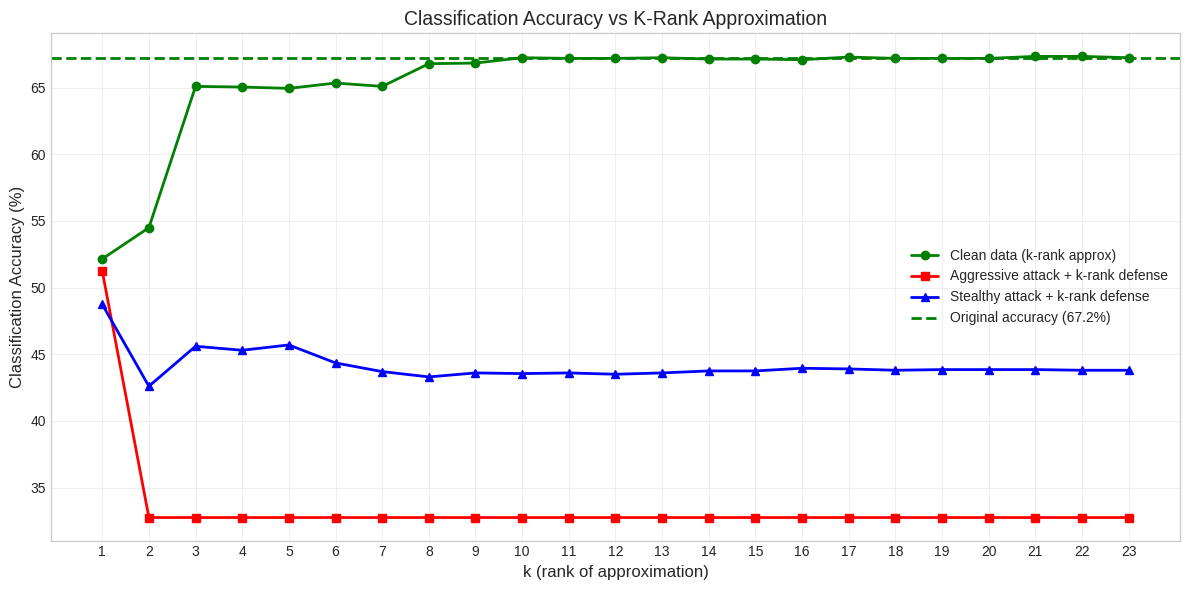


All k-rank analysis plots saved to k_rank_results/


In [32]:
# Plot accuracy vs k
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(accuracy_results['k'], np.array(accuracy_results['original_accuracy']) * 100, 
        marker='o', linewidth=2, color='green', label='Clean data (k-rank approx)')
ax.plot(accuracy_results['k'], np.array(accuracy_results['defended_aggressive_accuracy']) * 100, 
        marker='s', linewidth=2, color='red', label='Aggressive attack + k-rank defense')
ax.plot(accuracy_results['k'], np.array(accuracy_results['defended_stealthy_accuracy']) * 100, 
        marker='^', linewidth=2, color='blue', label='Stealthy attack + k-rank defense')

ax.axhline(y=original_accuracy * 100, color='green', linestyle='--', 
           label=f'Original accuracy ({original_accuracy:.1%})', linewidth=2)

ax.set_xlabel('k (rank of approximation)', fontsize=12)
ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
ax.set_title('Classification Accuracy vs K-Rank Approximation', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(K_VALUES)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'k_rank_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll k-rank analysis plots saved to {output_dir}/")